In [57]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

1. Data Import and Preprocessing

In [58]:
df=pd.read_csv('used_car_price_dataset_extended.csv')
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [60]:
#null values in dataset
df.isnull().sum()

make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

Encoding categorical columns:

In [61]:
#convert nan values to none
df['service_history']=df['service_history'].replace(np.nan,'None')
df['service_history'].value_counts()

service_history
Full       4987
Partial    2975
None       2038
Name: count, dtype: int64

In [62]:
#unique values of all the objects
for column in df.select_dtypes(include=['object']).columns:
    unique_values = df[column].unique()
    print(f"Unique values in column '{column}': {unique_values}\n")

Unique values in column 'fuel_type': ['Petrol' 'Diesel' 'Electric']

Unique values in column 'brand': ['Chevrolet' 'Honda' 'BMW' 'Hyundai' 'Nissan' 'Tesla' 'Toyota' 'Kia'
 'Volkswagen' 'Ford']

Unique values in column 'transmission': ['Manual' 'Automatic']

Unique values in column 'color': ['White' 'Black' 'Blue' 'Red' 'Gray' 'Silver']

Unique values in column 'service_history': ['None' 'Full' 'Partial']

Unique values in column 'insurance_valid': ['No' 'Yes']



In [63]:
#change object to category for transmission,service_history,insurance_valid
#transmission to 0 and 1
df['transmission'] = df['transmission'].map({'Manual': 0, 'Automatic': 1})
#service_history to 0,1,2
df['service_history'] = df['service_history'].map({'None': 0, 'Partial': 1, 'Full': 2})
#insurance_valid to 0 and 1
df['insurance_valid'] = df['insurance_valid'].map({'No': 0, 'Yes': 1})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  int64  
 8   color               10000 non-null  object 
 9   service_history     10000 non-null  int64  
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 937.6+ KB


In [64]:
#one hot encoding for brand,fuel_type,body_type
df=pd.get_dummies(df,columns=['brand','fuel_type','color'],drop_first=True)
#convert bool to 0,1
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
df.head()


,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,transmission,service_history,accidents_reported,insurance_valid,brand_Chevrolet,...,brand_Tesla,brand_Toyota,brand_Volkswagen,fuel_type_Electric,fuel_type_Petrol,color_Blue,color_Gray,color_Red,color_Silver,color_White
0,2001,8.17,4000,4,8587.64,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2014,17.59,1500,4,5943.50,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,2023,18.09,2500,5,9273.58,1,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,2009,11.28,800,1,6836.24,0,2,0,1,0,...,0,0,0,0,1,1,0,0,0,0
4,2005,12.23,1000,2,4625.79,1,2,0,1,0,...,0,0,0,0,1,0,0,1,0,0


Feature Engineering and Model Selection:

In [65]:
#dependetn and independent features
X=df.drop('price_usd',axis=1)
y=df['price_usd']

In [66]:
#find skewness of mileage and engine_cc
print("Skewness of mileage:", X['mileage_kmpl'].skew())
print("Skewness of engine_cc:", X['engine_cc'].skew())
#power transform
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer()
X[['mileage_kmpl', 'engine_cc']] = pt.fit_transform(X[['mileage_kmpl', 'engine_cc']])
print("Skewness of mileage after power transform:", X['mileage_kmpl'].skew())
print("Skewness of engine_cc after power transform:", X['engine_cc'].skew())
X.head()

Skewness of mileage: 0.021491677278585322
Skewness of engine_cc: 0.8497869170972214
Skewness of mileage after power transform: -0.0162016856468388
Skewness of engine_cc after power transform: 0.019614764387753225


,make_year,mileage_kmpl,engine_cc,owner_count,transmission,service_history,accidents_reported,insurance_valid,brand_Chevrolet,brand_Ford,...,brand_Tesla,brand_Toyota,brand_Volkswagen,fuel_type_Electric,fuel_type_Petrol,color_Blue,color_Gray,color_Red,color_Silver,color_White
0,2001,-1.968341,1.260608,4,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
1,2014,-0.067129,-0.454258,4,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,2023,0.032226,0.459827,5,1,2,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2009,-1.333410,-1.644882,1,0,2,0,1,0,0,...,0,0,0,0,1,1,0,0,0,0
4,2005,-1.141089,-1.213693,2,1,2,0,1,0,0,...,0,0,0,0,1,0,0,1,0,0


R2 Score: 0.8527365366083425


 99%|===================| 1978/2000 [01:32<00:01]        

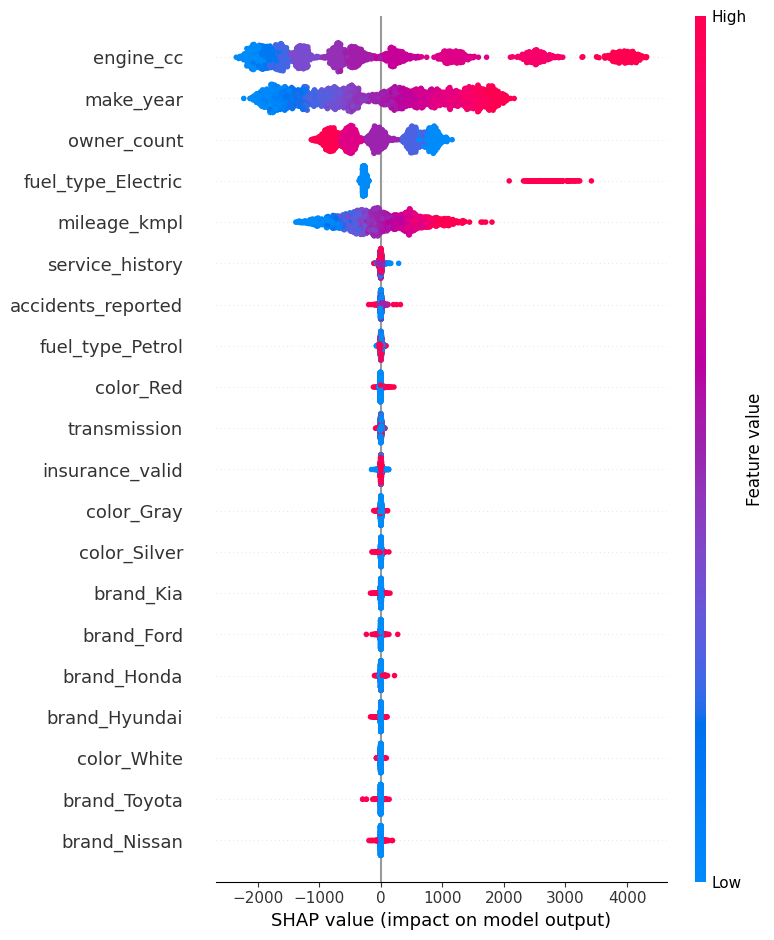

In [69]:
#random forest regressor model and shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
import shap
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)


In [70]:
#drop all color columns and brand columns
cols_to_drop = [col for col in X.columns if col.startswith('color_') or col.startswith('brand_')]
X_reduced = X.drop(columns=cols_to_drop)
X_reduced.head()



,make_year,mileage_kmpl,engine_cc,owner_count,transmission,service_history,accidents_reported,insurance_valid,fuel_type_Electric,fuel_type_Petrol
0,2001,-1.968341,1.260608,4,0,0,0,0,0,1
1,2014,-0.067129,-0.454258,4,0,0,0,1,0,1
2,2023,0.032226,0.459827,5,1,2,1,1,0,0
3,2009,-1.333410,-1.644882,1,0,2,0,1,0,1
4,2005,-1.141089,-1.213693,2,1,2,0,1,0,1


In [71]:
X_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  float64
 3   owner_count         10000 non-null  int64  
 4   transmission        10000 non-null  int64  
 5   service_history     10000 non-null  int64  
 6   accidents_reported  10000 non-null  int64  
 7   insurance_valid     10000 non-null  int64  
 8   fuel_type_Electric  10000 non-null  int64  
 9   fuel_type_Petrol    10000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 781.4 KB


In [72]:
#random forest regressor model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
print("R2 Score after dropping color and brand columns:", r2)


R2 Score after dropping color and brand columns: 0.8501866187533782


In [73]:
#xgboost model
import xgboost as xgb
model_xgb = xgb.XGBRegressor(objective ='reg:squarederror', n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
print("XGBoost R2 Score after dropping color and brand columns:", r2_xgb)


XGBoost R2 Score after dropping color and brand columns: 0.8475883478260484


In [74]:
#lightgbm model
import lightgbm as lgb
model_lgb = lgb.LGBMRegressor(n_estimators=100, random_state=42)
model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)
r2_lgb = r2_score(y_test, y_pred_lgb)
print("LightGBM R2 Score after dropping color and brand columns:", r2_lgb)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000685 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] Start training from score 7196.293336
LightGBM R2 Score after dropping color and brand columns: 0.8689121580077104


In [77]:
#mae for lightgbm
from sklearn.metrics import mean_absolute_error
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
print("LightGBM Mean Absolute Error :", mae_lgb)
#calculate percentage mae
percentage_mae = (mae_lgb / y_test.mean()) * 100
print("LightGBM Percentage Mean Absolute Error :", percentage_mae)

LightGBM Mean Absolute Error : 811.8406165929692
LightGBM Percentage Mean Absolute Error : 11.41251538979841


Error Analysis:

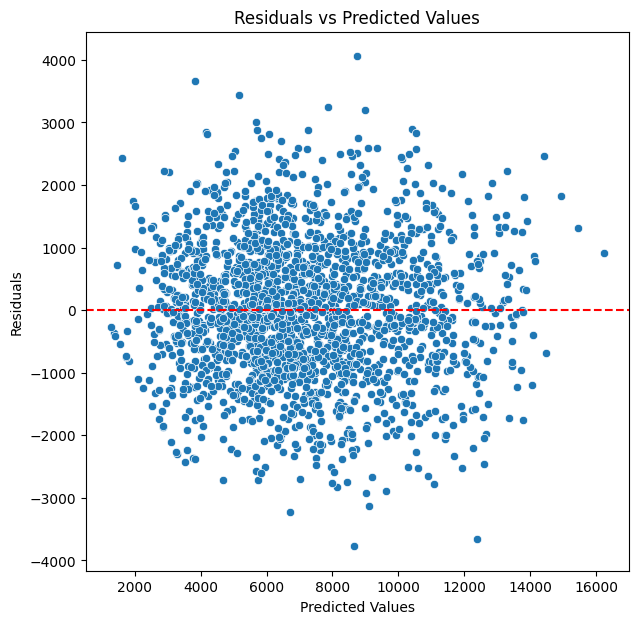

In [80]:
residuals = y_test - y_pred
plt.figure(figsize=(7,7))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.show()


Saving the best model:

In [81]:
#saving the model
import joblib
joblib.dump(model_lgb, 'used_car_price_lgb_model.pkl')


['used_car_price_lgb_model.pkl']